In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reload raw data
df = pd.read_csv(r"C:\Users\NB00569\Projects\energy-demand-forecasting\data\raw\PJME_hourly.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
df.columns = ['energy_mw']

# Find suspiciously low values
# Real grid minimum is around 19,000 MW based on our EDA
threshold_low = 19000

suspicious = df[df['energy_mw'] < threshold_low]

print(f"Suspiciously low values (< {threshold_low:,} MW):")
print(f"Count : {len(suspicious)}")
print(f"\nDetails:")
print(suspicious)

Suspiciously low values (< 19,000 MW):
Count : 15

Details:
                     energy_mw
Datetime                      
2012-10-29 23:00:00    17422.0
2012-10-30 00:00:00    15919.0
2012-10-30 01:00:00    15390.0
2012-10-30 02:00:00    14955.0
2012-10-30 03:00:00    14586.0
2012-10-30 04:00:00    14544.0
2012-10-30 05:00:00    14821.0
2012-10-30 06:00:00    15526.0
2012-10-30 07:00:00    16688.0
2012-10-30 08:00:00    17734.0
2012-10-30 09:00:00    18675.0
2012-10-31 02:00:00    18618.0
2012-10-31 03:00:00    18350.0
2012-10-31 04:00:00    18330.0
2012-10-31 05:00:00    18880.0


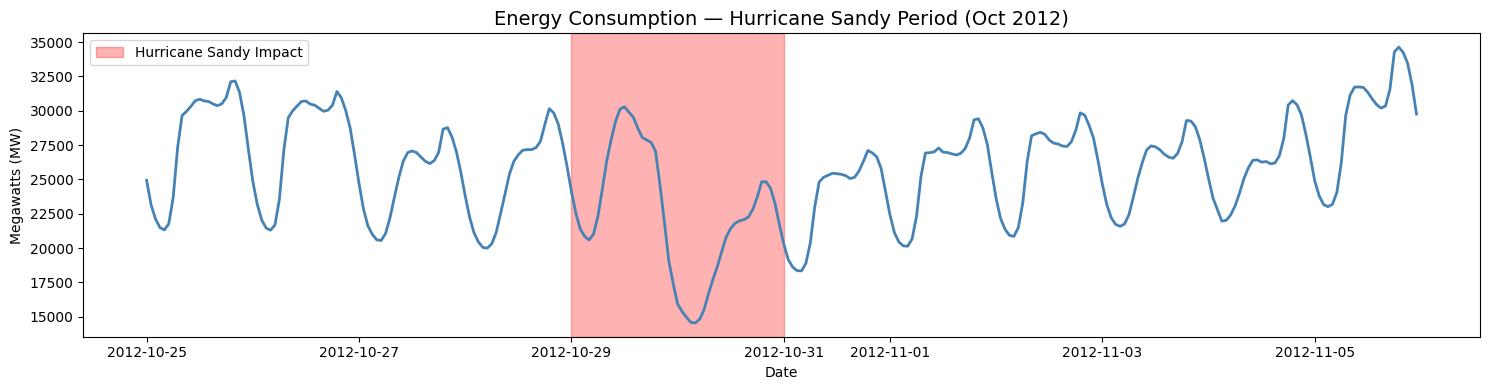

✅ Plot saved successfully


In [3]:
import os

# Create directory if it doesn't exist
os.makedirs('../results/plots', exist_ok=True)

# Save the plot again
sandy_period = df.loc['2012-10-25':'2012-11-05']

plt.figure(figsize=(15, 4))
plt.plot(sandy_period['energy_mw'], 
         linewidth=2, color='steelblue')
plt.axvspan(pd.Timestamp('2012-10-29'), 
            pd.Timestamp('2012-10-31'),
            alpha=0.3, color='red', 
            label='Hurricane Sandy Impact')
plt.title('Energy Consumption — Hurricane Sandy Period (Oct 2012)', 
          fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/08_hurricane_sandy.png', dpi=150)
plt.show()

print("✅ Plot saved successfully")

1st  Percentile : 20,970 MW
99th Percentile : 51,155 MW

Before capping:
Min : 20,969 MW
Max : 51,156 MW

After capping:
Min : 20,970 MW
Max : 51,155 MW


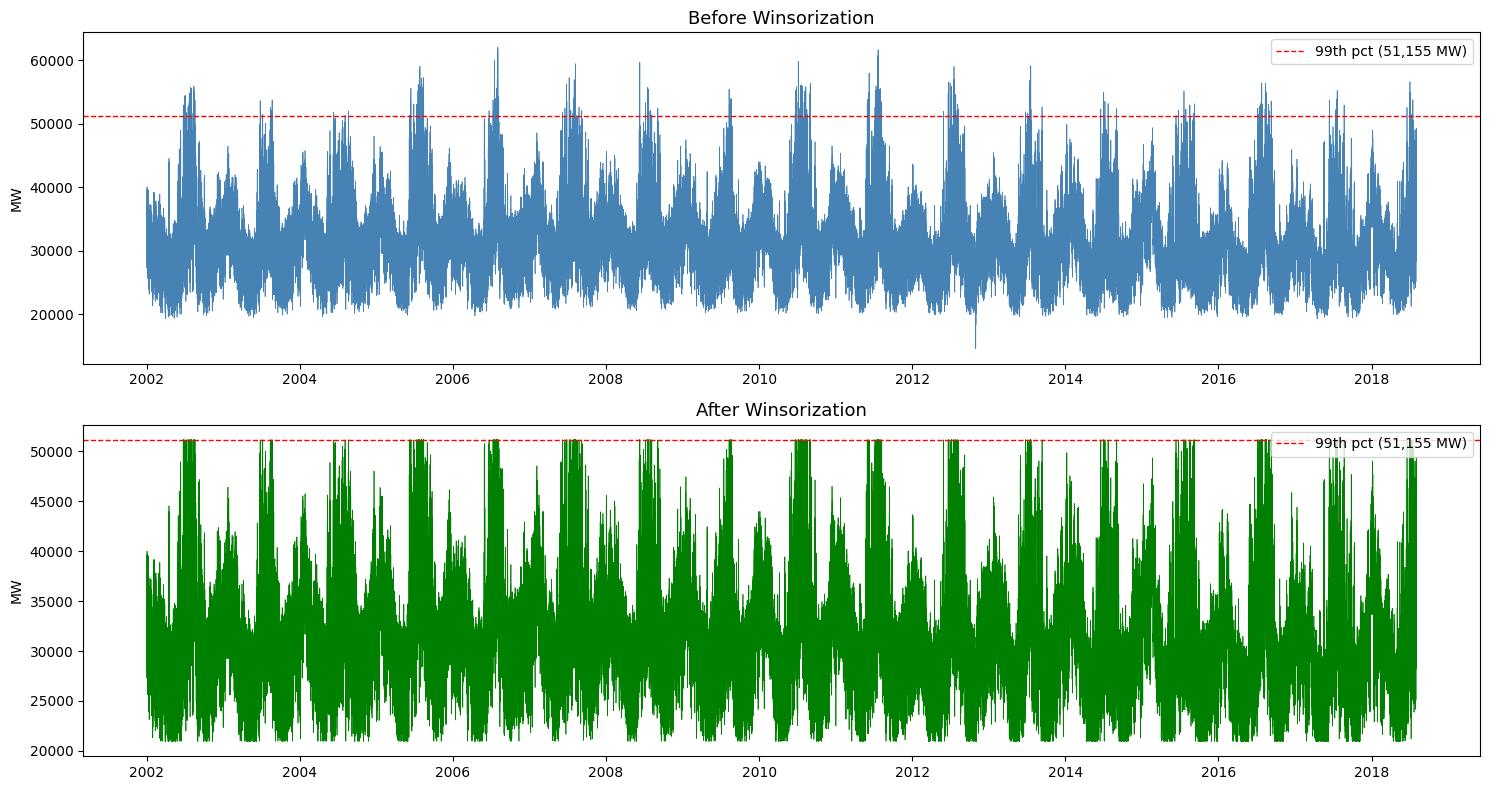


✅ Winsorization complete


In [5]:
# Calculate 1st and 99th percentile boundaries
p01 = df['energy_mw'].quantile(0.01)
p99 = df['energy_mw'].quantile(0.99)

print(f"1st  Percentile : {p01:,.0f} MW")
print(f"99th Percentile : {p99:,.0f} MW")
print(f"\nBefore capping:")
print(f"Min : {df['energy_mw'].min():,.0f} MW")
print(f"Max : {df['energy_mw'].max():,.0f} MW")

# Apply Winsorization
df['energy_mw'] = df['energy_mw'].clip(lower=p01, upper=p99)

print(f"\nAfter capping:")
print(f"Min : {df['energy_mw'].min():,.0f} MW")
print(f"Max : {df['energy_mw'].max():,.0f} MW")

# Visualize before vs after
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Reload original for comparison
df_original = pd.read_csv(r"C:\Users\NB00569\Projects\energy-demand-forecasting\data\raw\PJME_hourly.csv")
df_original['Datetime'] = pd.to_datetime(df_original['Datetime'])
df_original = df_original.set_index('Datetime').sort_index()
df_original.columns = ['energy_mw']

axes[0].plot(df_original['energy_mw'], 
             linewidth=0.5, color='steelblue')
axes[0].set_title('Before Winsorization', fontsize=13)
axes[0].set_ylabel('MW')
axes[0].axhline(y=p99, color='red', 
                linestyle='--', linewidth=1,
                label=f'99th pct ({p99:,.0f} MW)')
axes[0].legend()

axes[1].plot(df['energy_mw'], 
             linewidth=0.5, color='green')
axes[1].set_title('After Winsorization', fontsize=13)
axes[1].set_ylabel('MW')
axes[1].axhline(y=p99, color='red', 
                linestyle='--', linewidth=1,
                label=f'99th pct ({p99:,.0f} MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/09_winsorization.png', dpi=150)
plt.show()

print("\n✅ Winsorization complete")

Hourly data shape : (145366, 1)
Daily data shape  : (6059, 1)

First 5 rows:
               energy_mw
Datetime                
2002-01-01  31080.739130
2002-01-02  34261.541667
2002-01-03  34511.875000
2002-01-04  33715.458333
2002-01-05  30405.125000

Last 5 rows:
               energy_mw
Datetime                
2018-07-30  32957.416667
2018-07-31  34539.083333
2018-08-01  39230.791667
2018-08-02  39593.041667
2018-08-03  35486.000000

Any missing values: 0


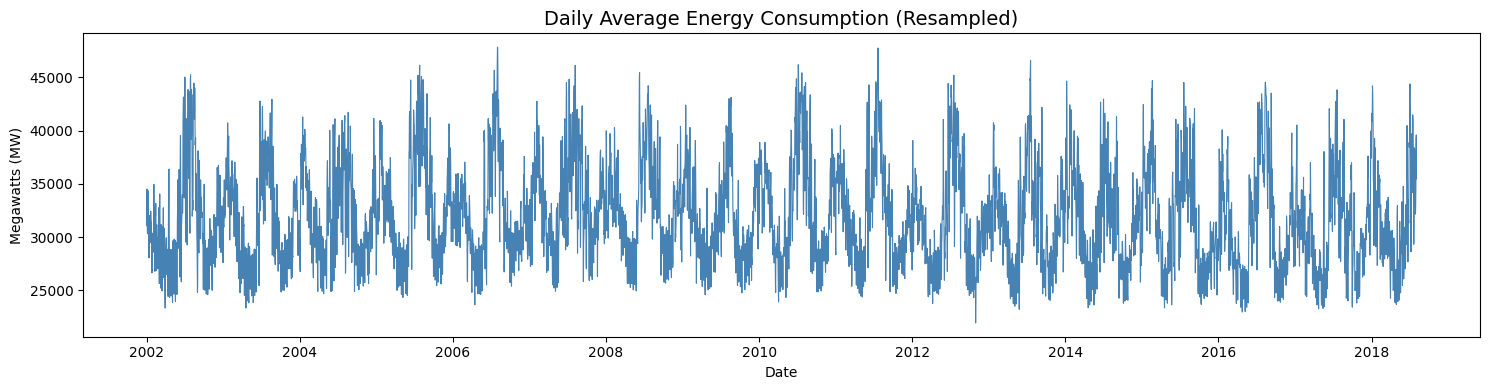

✅ Resampling complete


In [6]:
# Resample hourly to daily (using mean)
df_daily = df['energy_mw'].resample('D').mean()

# Convert to DataFrame
df_daily = df_daily.to_frame()
df_daily.columns = ['energy_mw']

print(f"Hourly data shape : {df.shape}")
print(f"Daily data shape  : {df_daily.shape}")
print(f"\nFirst 5 rows:")
print(df_daily.head())
print(f"\nLast 5 rows:")
print(df_daily.tail())
print(f"\nAny missing values: {df_daily.isnull().sum().values[0]}")

# Plot daily resampled data
plt.figure(figsize=(15, 4))
plt.plot(df_daily['energy_mw'], 
         linewidth=0.8, color='steelblue')
plt.title('Daily Average Energy Consumption (Resampled)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.savefig('../results/plots/10_daily_resampled.png', dpi=150)
plt.show()

print("✅ Resampling complete")

In [7]:
# Create a copy for feature engineering
df_featured = df_daily.copy()

# Extract time-based features
df_featured['year']        = df_featured.index.year
df_featured['month']       = df_featured.index.month
df_featured['day_of_week'] = df_featured.index.dayofweek
df_featured['day_of_year'] = df_featured.index.dayofyear
df_featured['quarter']     = df_featured.index.quarter
df_featured['is_weekend']  = (df_featured.index.dayofweek >= 5).astype(int)

# Add lag features (previous days' demand)
df_featured['lag_1']  = df_featured['energy_mw'].shift(1)   # yesterday
df_featured['lag_7']  = df_featured['energy_mw'].shift(7)   # last week
df_featured['lag_365']= df_featured['energy_mw'].shift(365) # last year

# Add rolling mean features
df_featured['rolling_mean_7']  = df_featured['energy_mw'].shift(1).rolling(7).mean()
df_featured['rolling_mean_30'] = df_featured['energy_mw'].shift(1).rolling(30).mean()

# Drop rows with NaN (from lag/rolling features)
df_featured = df_featured.dropna()

print(f"Shape after feature engineering: {df_featured.shape}")
print(f"\nFeature columns:")
for col in df_featured.columns:
    print(f"  → {col}")
print(f"\nFirst 3 rows:")
df_featured.head(3)

Shape after feature engineering: (5694, 12)

Feature columns:
  → energy_mw
  → year
  → month
  → day_of_week
  → day_of_year
  → quarter
  → is_weekend
  → lag_1
  → lag_7
  → lag_365
  → rolling_mean_7
  → rolling_mean_30

First 3 rows:


,energy_mw,year,month,day_of_week,day_of_year,quarter,is_weekend,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
Datetime,,,,,,,,,,,,
2003-01-01,27603.708333,2003,1,2,1,1,0,29560.958333,29533.875000,31080.739130,30905.273810,32657.780556
2003-01-02,32118.750000,2003,1,3,2,1,0,27603.708333,32106.500000,34261.541667,30629.535714,32478.095833
2003-01-03,33701.750000,2003,1,4,3,1,0,32118.750000,32936.333333,34511.875000,30631.285714,32377.193056


Split date      : 2017-01-01

Training set:
  Start         : 2003-01-01
  End           : 2016-12-31
  Shape         : (5114, 12)
  Years         : 2003 → 2016

Test set:
  Start         : 2017-01-01
  End           : 2018-08-03
  Shape         : (580, 12)
  Years         : 2017 → 2018

Train/Test ratio: 89.8% / 10.2%


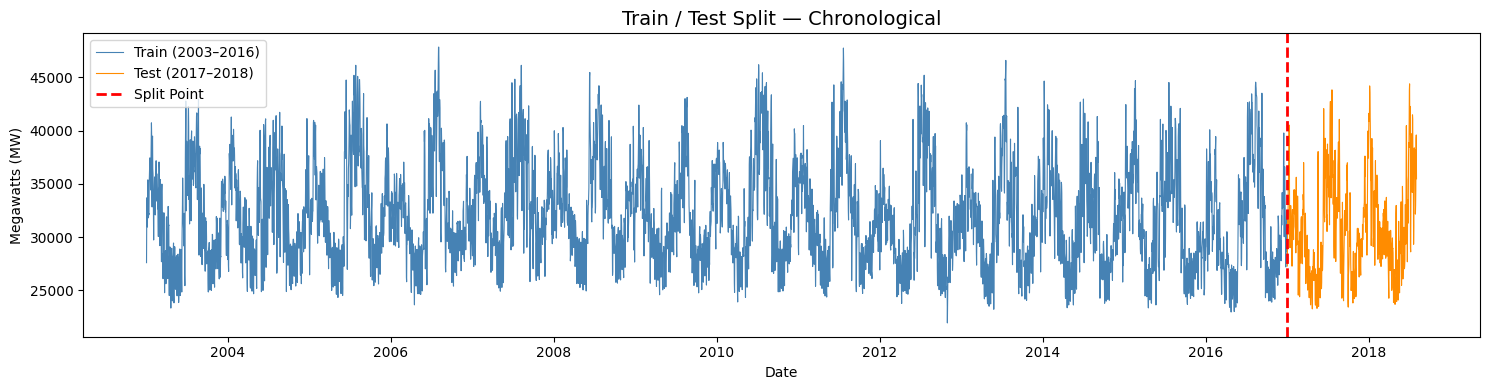

In [8]:
# Split date — use last ~1.5 years as test set
split_date = '2017-01-01'

# Chronological split
train = df_featured[df_featured.index < split_date]
test  = df_featured[df_featured.index >= split_date]

print(f"Split date      : {split_date}")
print(f"\nTraining set:")
print(f"  Start         : {train.index.min().date()}")
print(f"  End           : {train.index.max().date()}")
print(f"  Shape         : {train.shape}")
print(f"  Years         : {train.index.min().year} → {train.index.max().year}")

print(f"\nTest set:")
print(f"  Start         : {test.index.min().date()}")
print(f"  End           : {test.index.max().date()}")
print(f"  Shape         : {test.shape}")
print(f"  Years         : {test.index.min().year} → {test.index.max().year}")

print(f"\nTrain/Test ratio: "
      f"{len(train)/len(df_featured)*100:.1f}% / "
      f"{len(test)/len(df_featured)*100:.1f}%")

# Visualize the split
plt.figure(figsize=(15, 4))
plt.plot(train['energy_mw'], 
         linewidth=0.8, 
         color='steelblue', 
         label=f'Train ({train.index.min().year}–{train.index.max().year})')
plt.plot(test['energy_mw'],  
         linewidth=0.8, 
         color='darkorange', 
         label=f'Test ({test.index.min().year}–{test.index.max().year})')
plt.axvline(x=pd.Timestamp(split_date), 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label='Split Point')
plt.title('Train / Test Split — Chronological', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/11_train_test_split.png', dpi=150)
plt.show()

In [9]:
import os

# Ensure directories exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# Save 1 — Clean daily data (no features)
df_daily.to_csv('../data/processed/pjme_daily_clean.csv')
print(f"✅ Saved: pjme_daily_clean.csv     {df_daily.shape}")

# Save 2 — Featured data (with all engineered features)
df_featured.to_csv('../data/processed/pjme_daily_featured.csv')
print(f"✅ Saved: pjme_daily_featured.csv  {df_featured.shape}")

# Save 3 — Train set
train.to_csv('../data/processed/train.csv')
print(f"✅ Saved: train.csv                {train.shape}")

# Save 4 — Test set
test.to_csv('../data/processed/test.csv')
print(f"✅ Saved: test.csv                 {test.shape}")

# Save preprocessing summary
summary = {
    'raw_hourly_rows'      : 145366,
    'daily_rows'           : len(df_daily),
    'featured_rows'        : len(df_featured),
    'train_rows'           : len(train),
    'test_rows'            : len(test),
    'train_start'          : str(train.index.min().date()),
    'train_end'            : str(train.index.max().date()),
    'test_start'           : str(test.index.min().date()),
    'test_end'             : str(test.index.max().date()),
    'features'             : list(df_featured.columns),
    'outlier_method'       : 'Winsorization (1st-99th percentile)',
    'resample_method'      : 'Daily mean',
    'split_method'         : 'Chronological',
}

import json
with open('../results/metrics/preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print(f"\n✅ Saved: preprocessing_summary.json")
print(f"\n📁 All processed files saved to data/processed/")

✅ Saved: pjme_daily_clean.csv     (6059, 1)
✅ Saved: pjme_daily_featured.csv  (5694, 12)
✅ Saved: train.csv                (5114, 12)
✅ Saved: test.csv                 (580, 12)

✅ Saved: preprocessing_summary.json

📁 All processed files saved to data/processed/


In [10]:
print('=' * 55)
print('     PREPROCESSING SUMMARY')
print('=' * 55)
print(f'\n📥 INPUT')
print(f'   Raw hourly rows     : 145,366')
print(f'   Date range          : 2002 → 2018')

print(f'\n🔧 STEPS PERFORMED')
print(f'   1. Parsed datetime index')
print(f'   2. Investigated low values → Hurricane Sandy')
print(f'   3. Winsorized outliers (1st–99th percentile)')
print(f'   4. Resampled hourly → daily (mean)')
print(f'   5. Engineered 11 time-based features')
print(f'   6. Chronological train/test split')

print(f'\n📤 OUTPUT')
print(f'   Daily clean rows    : {len(df_daily):,}')
print(f'   Featured rows       : {len(df_featured):,}')
print(f'   Train rows          : {len(train):,}')
print(f'   Test rows           : {len(test):,}')
print(f'   Features created    : 11')

print(f'\n✂️  SPLIT')
print(f'   Train               : 2003–2016 (89.8%)')
print(f'   Test                : 2017–2018 (10.2%)')
print(f'   Method              : Chronological (no leakage)')

print(f'\n📁 FILES SAVED')
print(f'   data/processed/pjme_daily_clean.csv')
print(f'   data/processed/pjme_daily_featured.csv')
print(f'   data/processed/train.csv')
print(f'   data/processed/test.csv')
print(f'   results/metrics/preprocessing_summary.json')
print('=' * 55)

     PREPROCESSING SUMMARY

📥 INPUT
   Raw hourly rows     : 145,366
   Date range          : 2002 → 2018

🔧 STEPS PERFORMED
   1. Parsed datetime index
   2. Investigated low values → Hurricane Sandy
   3. Winsorized outliers (1st–99th percentile)
   4. Resampled hourly → daily (mean)
   5. Engineered 11 time-based features
   6. Chronological train/test split

📤 OUTPUT
   Daily clean rows    : 6,059
   Featured rows       : 5,694
   Train rows          : 5,114
   Test rows           : 580
   Features created    : 11

✂️  SPLIT
   Train               : 2003–2016 (89.8%)
   Test                : 2017–2018 (10.2%)
   Method              : Chronological (no leakage)

📁 FILES SAVED
   data/processed/pjme_daily_clean.csv
   data/processed/pjme_daily_featured.csv
   data/processed/train.csv
   data/processed/test.csv
   results/metrics/preprocessing_summary.json
